# RL Snake — Tutorial

This notebook walks you through the `rl_snake` package: how to create the environment, interact with it step-by-step, visualise observations, and run a **random agent** demo with an animation.

---
**Grid encoding:**

| Value | Meaning |
|-------|---------|
| 0 | empty |
| 1 | snake body |
| 2 | snake head |
| 3 | gold food (high reward) |
| 4 | silver food (medium reward) |
| 5 | poison food (shrinks snake) |
| 6 | obstacle (static or dynamic) |

**Actions:** `0=UP`, `1=RIGHT`, `2=DOWN`, `3=LEFT`

In [1]:
import sys

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from rl_snake import SnakeEnv, StepResult, render_observation, make_animation
from rl_snake.agent import get_state, get_grid_state, DQNAgent, CNNDQNAgent

# Show animations inline
matplotlib.rcParams["animation.embed_limit"] = 50  # MB
from IPython.display import HTML

## 1  Creating the Environment

`SnakeEnv` is fully configurable. Here we create a basic 10×10 grid with one gold food item.

In [2]:
env = SnakeEnv(
    height=10,
    width=10,
    init_length=3,
    seed=42,
    gold_reward=1.0,
    death_reward=-1.0,
    step_reward=0.0,
    n_gold=1,
    max_steps=200,
)

obs = env.reset()

print(f"Grid size    : {env.height} × {env.width}")
print(f"Snake length : {env.length}")
print(f"Snake head   : {env.snake[0]}")
print(f"Food pos     : {env.food}")
print(f"Observation  :\n{obs}")

Grid size    : 10 × 10
Snake length : 3
Snake head   : (5, 5)
Food pos     : (4, 7)
Observation  :
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 3 0 0]
 [0 0 0 1 1 2 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


## 2  Visualising the Grid

`render_observation` turns the raw 2-D numpy array into a colour-coded Matplotlib figure.

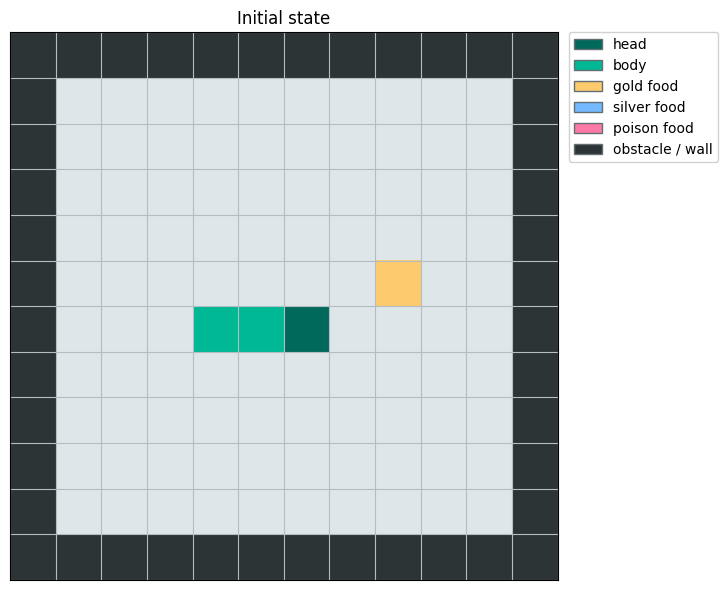

In [3]:
fig, ax = render_observation(obs, title="Initial state")
plt.tight_layout()
plt.show()

## 3  Stepping the Environment Manually

Each call to `env.step(action)` returns a `StepResult(observation, reward, done, info)`.

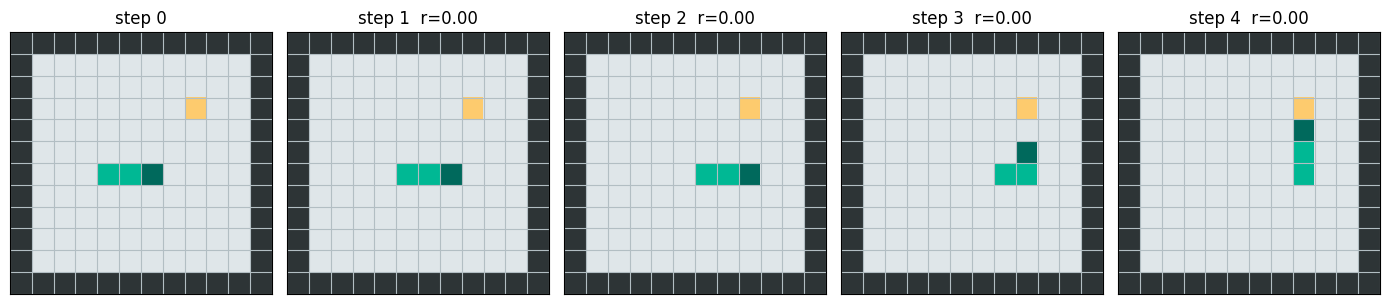

In [4]:
env.reset()

# Take four steps: right, right, up, up
UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
actions = [RIGHT, RIGHT, UP, UP]

fig, axes = plt.subplots(1, len(actions) + 1, figsize=(14, 3))
render_observation(env._get_observation(), ax=axes[0], title="step 0", legend=False)

for i, action in enumerate(actions, start=1):
    result = env.step(action)
    render_observation(
        result.observation,
        ax=axes[i],
        title=f"step {i}  r={result.reward:.2f}",
        legend=False,
    )

plt.tight_layout()
plt.show()

## 4  State Representations

Two state extractors are available for different agent architectures:

| Function | Output shape | Used by |
|---|---|---|
| `get_state(env)` | `(15,)` float vector | MLP agent (`DQNAgent`) |
| `get_grid_state(env)` | `(6, H, W)` binary grid | CNN agent (`CNNDQNAgent`) |

### 4.1  15-Feature Vector

In [5]:
env.reset()
state_vec = get_state(env)

feature_names = [
    "danger straight",
    "danger right (rel)",
    "danger left (rel)",
    "moving up",
    "moving right",
    "moving down",
    "moving left",
    "food above",
    "food below",
    "food left",
    "food right",
    "poison above",
    "poison below",
    "poison left",
    "poison right",
]

print("15-feature state vector:")
for name, val in zip(feature_names, state_vec):
    print(f"  {name:<25} {val:.0f}")

15-feature state vector:
  danger straight           0
  danger right (rel)        0
  danger left (rel)         0
  moving up                 0
  moving right              1
  moving down               0
  moving left               0
  food above                0
  food below                1
  food left                 1
  food right                0
  poison above              0
  poison below              0
  poison left               0
  poison right              0


### 4.2  6-Channel Binary Grid

Grid state shape: (6, 10, 10)  (channels × H × W)


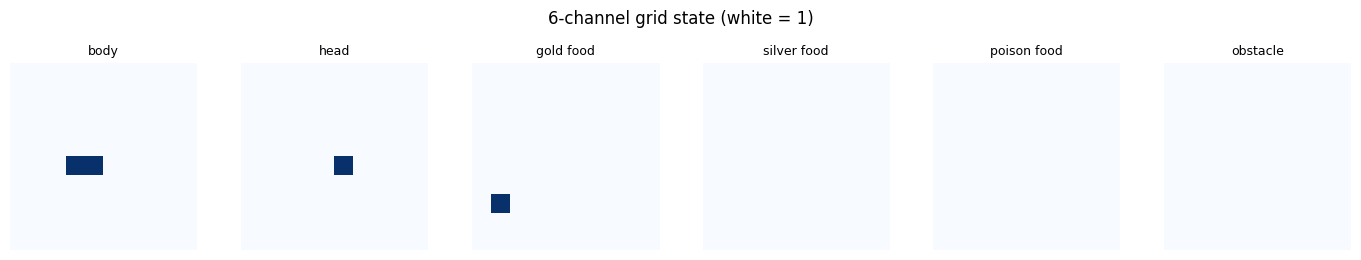

In [6]:
grid_state = get_grid_state(env)
channel_names = ["body", "head", "gold food", "silver food", "poison food", "obstacle"]

print(f"Grid state shape: {grid_state.shape}  (channels × H × W)")
fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
for ch, (ax, name) in enumerate(zip(axes, channel_names)):
    ax.imshow(grid_state[ch], cmap="Blues", vmin=0, vmax=1)
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.suptitle("6-channel grid state (white = 1)", y=1.02)
plt.tight_layout()
plt.show()

## 5  Random Agent Demo

A **random agent** picks a uniformly random action at every step. We wrap it in a minimal class so it is compatible with `make_animation`.

In [7]:
class RandomAgent:
    """Picks a uniform random action, regardless of state."""

    def __init__(self, n_actions: int = 4, seed: int | None = None):
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)

    def select_action(self, state) -> int:
        return int(self.rng.integers(self.n_actions))


random_agent = RandomAgent(seed=0)

In [8]:
# Run a full episode and collect stats
env_demo = SnakeEnv(
    height=10,
    width=10,
    init_length=3,
    seed=7,
    gold_reward=1.0,
    death_reward=-1.0,
    max_steps=300,
)

obs = env_demo.reset()
total_reward = 0.0
steps = 0

while True:
    state = get_state(env_demo)
    action = random_agent.select_action(state)
    result = env_demo.step(action)
    total_reward += result.reward
    steps += 1
    if result.done:
        break

print(f"Episode finished after {steps} steps")
print(f"Final snake length : {result.info['length']}")
print(f"Total reward       : {total_reward:.2f}")

Episode finished after 19 steps
Final snake length : 3
Total reward       : -1.00


### 5.1  Animated Rollout

`make_animation` runs a fresh episode and returns a `FuncAnimation` object.

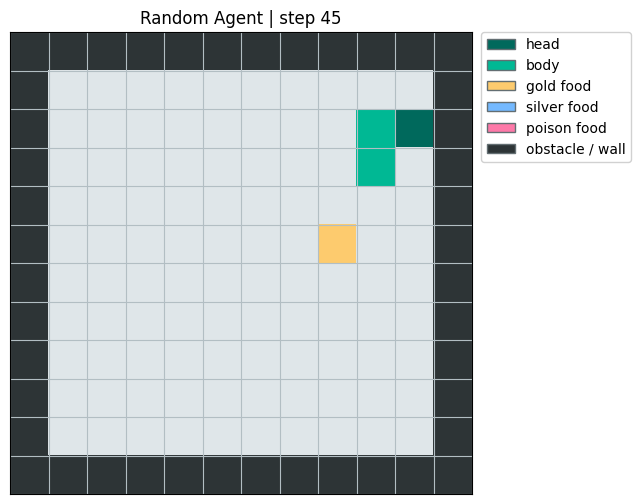

In [9]:
env_anim = SnakeEnv(
    height=10,
    width=10,
    init_length=3,
    seed=42,
    gold_reward=1.0,
    death_reward=-1.0,
    max_steps=200,
)

anim = make_animation(
    env=env_anim,
    agent=RandomAgent(seed=1),
    get_state=get_state,
    max_frames=150,
    interval=120,
    title="Random Agent",
)

HTML(anim.to_jshtml())

## 6  Advanced Environment Features

`SnakeEnv` supports mixed food types, static obstacles, and dynamic (moving) wall segments.

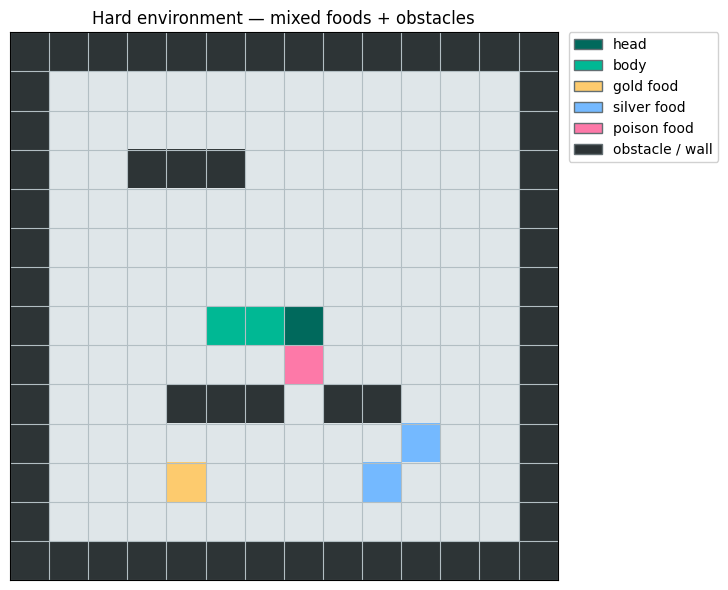

In [10]:
env_hard = SnakeEnv(
    height=12,
    width=12,
    seed=3,
    n_gold=1,
    n_silver=2,
    n_poison=1,
    gold_reward=1.0,
    silver_reward=0.5,
    poison_reward=-0.3,
    poison_shrink=2,
    obstacles=[(2, 2), (2, 3), (2, 4), (8, 7), (8, 8)],  # static walls
    n_dynamic_obstacles=1,  # one moving wall
    death_reward=-1.0,
    max_steps=300,
)

obs_hard = env_hard.reset()
fig, ax = render_observation(
    obs_hard, title="Hard environment — mixed foods + obstacles"
)
plt.tight_layout()
plt.show()

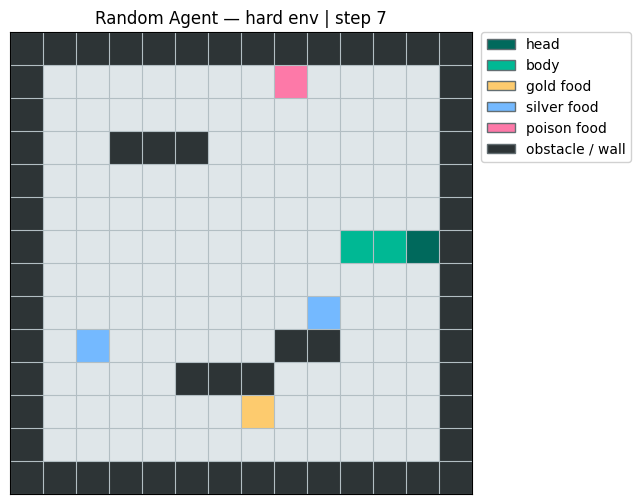

In [11]:
# Animate the random agent on the harder map
anim_hard = make_animation(
    env=env_hard,
    agent=RandomAgent(seed=2),
    get_state=get_state,
    max_frames=100,
    interval=150,
    title="Random Agent — hard env",
)

HTML(anim_hard.to_jshtml())

## 7  The DQN Agents (Overview)

Two trainable agents are provided:

| Class | Architecture | State input |
|---|---|---|
| `DQNAgent` | MLP (fully-connected) | 15-feature vector from `get_state` |
| `CNNDQNAgent` | CNN + MLP head | 6-channel grid from `get_grid_state` |

Both support **Double DQN**, **Dueling networks**, **frame stacking**, soft/hard target updates, and gradient clipping.

The cell below shows how to instantiate them (no training).

In [12]:
# MLP DQN agent
mlp_agent = DQNAgent(
    lr=1e-3,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    hidden=(256, 128),
    double_dqn=True,
    dueling=True,
)

# CNN DQN agent
cnn_agent = CNNDQNAgent(
    height=10,
    width=10,
    lr=1e-3,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    conv_channels=(32, 64),
    hidden=(512,),
    double_dqn=True,
    dueling=True,
)

print(mlp_agent.q_net)
print()
print(cnn_agent.q_net)

_QNetwork(
  (trunk): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (value_head): Linear(in_features=128, out_features=1, bias=True)
  (adv_head): Linear(in_features=128, out_features=4, bias=True)
)

_CNNQNetwork(
  (conv): Sequential(
    (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (fc_trunk): Sequential(
    (0): Linear(in_features=6400, out_features=512, bias=True)
    (1): ReLU()
  )
  (value_head): Linear(in_features=512, out_features=1, bias=True)
  (adv_head): Linear(in_features=512, out_features=4, bias=True)
)


### 7.1  Minimal Training Loop Sketch

Below is a condensed training loop illustrating how the agent integrates with the environment. 

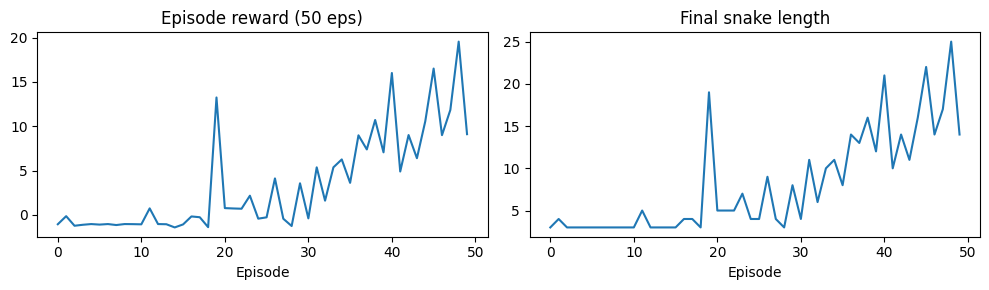

Final epsilon: 0.0100


In [13]:
from rl_snake.agent import FrameStack

train_env = SnakeEnv(
    height=10,
    width=10,
    seed=0,
    gold_reward=1.0,
    death_reward=-1.0,
    step_reward=-0.01,
    max_steps=200,
)

agent = DQNAgent(lr=1e-3, epsilon_decay=0.99)
frame_stack = FrameStack(n_frames=1, state_fn=get_state)

N_EPISODES = 50  # short demo — increase for real training
episode_rewards = []
episode_lengths = []

for ep in range(N_EPISODES):
    train_env.reset()
    state = frame_stack.reset(train_env)
    total_r = 0.0
    done = False

    while not done:
        action = agent.select_action(state)
        result = train_env.step(action)
        next_state = frame_stack.step(train_env)

        agent.store_transition(state, action, result.reward, next_state, result.done)
        agent.learn()

        total_r += result.reward
        state = next_state
        done = result.done

    episode_rewards.append(total_r)
    episode_lengths.append(result.info["length"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(episode_rewards)
axes[0].set_title(f"Episode reward ({N_EPISODES} eps)")
axes[0].set_xlabel("Episode")
axes[1].plot(episode_lengths)
axes[1].set_title("Final snake length")
axes[1].set_xlabel("Episode")
plt.tight_layout()
plt.show()

print(f"Final epsilon: {agent.epsilon:.4f}")